# Tarefa 01

- Leia os enunciados com atenção
- Saiba que pode haver mais de uma resposta correta
- Insira novas células de código sempre que achar necessário
- Em caso de dúvidas, procure os monitores
- Divirta-se :)

#### 1. Baixando dados de ativos
    1. Baixe os dados de três ativos da sua escolha do Yahoo Finance, correspondente a um período de pelo menos 2 anos até a data mais recente.
    2. Salve esses dados para que você possa utilizá-los na próxima tarefa.

In [3]:
import yfinance as yf

import os

# ativos escolhidos
ativos = ['AAPL', 'MSFT', 'TSLA']

# baixar dados (últimos 2 anos)
dados = yf.download(
    ativos,
    period='2y',
    interval='1d'
)
close = dados['Close']
close.head()

dados.head()

/tmp/ipykernel_55/1042384070.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        MSFT        TSLA        AAPL        MSFT   
Date                                                                     
2024-03-27  171.746964  415.059387  179.830002  172.034357  418.033754   
2024-03-28  169.933456  414.360077  175.789993  170.676692  415.492687   
2024-04-01  168.496536  418.151886  175.220001  169.705535  421.421706   
2024-04-02  167.317261  415.069244  166.630005  167.812751  415.995037   
2024-04-03  168.119965  414.094177  168.380005  169.140674  416.861697   

Price                          Low                                Open  \
Ticker            TSLA        AAPL        MSFT        TSLA        AAPL   
Date                                                                     
2024-03-27  181.910004  168.575826  412.675986  176.000000  168.873124   
2024-03-28  179.570007  168.972203  412.784258  175.300003  170.201026   
2024-04-01  176.750000  167.951494  415.837404  170.210007  169.646078   
2024-04-02  167.690002  166.712762  411.523658  163.429993  167.555102   
2024-04-03  168.820007  167.059623  412.754720  163.279999  167.267720   

Price                                 Volume                       
Ticker            MSFT        TSLA      AAPL      MSFT       TSLA  
Date                                                               
2024-03-27  418.023896  181.410004  60273300  16705000   81804000  
2024-03-28  414.596439  177.449997  65672700  21871200   77654800  
2024-04-01  417.541263  176.169998  46240500  16316000   81562100  
2024-04-02  413.759333  164.750000  49329500  17912000  116650600  
2024-04-03  413.385060  164.020004  47691700  16502300   82950100

In [4]:
close.to_csv('/kaggle/working/ativos_close.csv')

print(os.listdir('/kaggle/working'))

['ativos_close.csv', '.virtual_documents']


#### 2. Observando a volatilidade dentro do dia
1. Calcule a amplitude de variação do valor do ativo dentro do dia. Essa amplitude você pode calcular com um comando simples de adicionar uma coluna no Pandas: (valor máximo - valor mínimo).
2. Monte um gráfico de linha mostrando a variação dessa amplitude ao longo do período coletado, por ativo.
3. Veja se consegue identificar que ativo apresentou maior volatilidade.

In [5]:
# calcular amplitude para cada ativo
amplitude = dados['High'] - dados['Low']

amplitude.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2024-03-27,3.458530,5.357768,5.910004
2024-03-28,1.704489,2.708429,4.270004
2024-04-01,1.754041,5.584301,6.539993
2024-04-02,1.099990,4.471379,4.260010
2024-04-03,2.081052,4.106976,5.540009


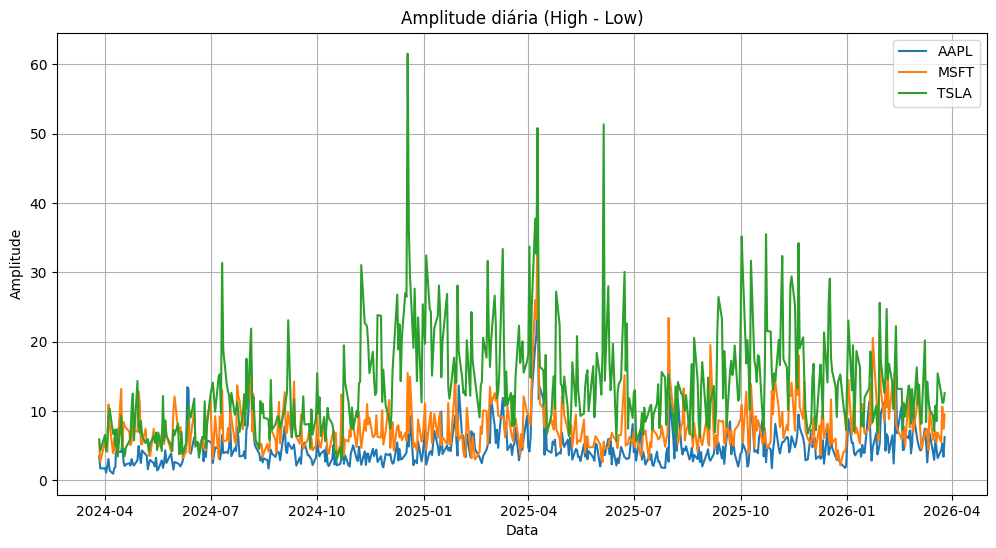

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for ativo in amplitude.columns:
    plt.plot(amplitude.index, amplitude[ativo], label=ativo)

plt.title('Amplitude diária (High - Low)')
plt.xlabel('Data')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.show()

In [7]:
media_volatilidade = amplitude.mean()

print(media_volatilidade)

Ticker
AAPL     4.688437
MSFT     7.742372
TSLA    13.728842
dtype: float64


A amplitude diária foi calculada como a diferença entre os valores máximos e mínimos de cada ativo.
O gráfico da amplitude ao longo do tempo evidencia que o ativo TSLA apresenta maior variabilidade, com picos mais elevados e maior dispersão dos valores.
A análise das médias confirma esse comportamento, com TSLA apresentando a maior média de amplitude (13.73), seguido por MSFT (7.74) e AAPL (4.69).
Portanto, conclui-se que o ativo TSLA é o mais volátil dentre os analisados, enquanto AAPL apresenta menor volatilidade.